# Algoritm Genetic pentru Sortarea unor numere ca Permutări

Acest notebook prezintă o implementare a unui Algoritm Genetic (AG) pentru problema sortării unei liste de numere. Este important de reținut că **acesta este un exemplu didactic, conceput în mod intenționat pentru a ilustra funcționarea AG-urilor pe problema permutărilor**, și nu o metodă eficientă de sortare în practică. Scopul principal este de a explora modul în care un AG poate găsi o soluție optimă (o listă sortată) prin evoluție, folosind operatori precum selecția, încrucișarea și mutația.

In [1]:
# Importul bibliotecilor necesare pentru implementarea algoritmului genetic și vizualizarea datelor.
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importuri necesare

În această secțiune sunt importate bibliotecile necesare pentru implementarea algoritmului genetic și pentru vizualizarea rezultatelor.

In [2]:
# Definirea lungimii cromozomului, reprezentând numărul de elemente din permutare.
chromozome_lenght = 21
# Definirea setului de elemente valide care compun cromozomul (0-20 pentru sortare).
valid_chromozome = list(range(chromozome_lenght))

### Definirea Cromozomului și a Spațiului de Căutare

Variabilele `chromozome_lenght` și `valid_chromozome` definesc structura "cromozomului" (o listă de numere) și valorile posibile pe care le poate conține. În acest caz, căutăm o permutare a numerelor de la 0 la 20.

*   `chromozome_lenght`: Lungimea listei (permutării).
*   `valid_chromozome`: O listă cu toate elementele unice pe care "cromozomul" ar trebui să le conțină în permutarea sa sortată.

In [3]:
# print(valid_chromozome)

In [4]:
# print("".join(str(valid_chromozome)))

In [5]:
def generate_individual(valid_chromozome, rng=random):
  """Generează o permutare aleatoare a elementelor valide, reprezentând un individ nou.

  Args:
    valid_chromozome (list): Lista elementelor care pot fi incluse în cromozom.
    rng (random.Random sau random): Generatorul de numere aleatoare utilizat pentru reproducibilitate.

  Returns:
    list: O permutare aleatoare a elementelor.
  """
  return rng.sample(valid_chromozome, len(valid_chromozome))

### Generarea unei Permutări Inițiale (Individ)

Funcția `generate_individual` creează o permutare aleatorie a elementelor din `valid_chromozome`. Aceasta reprezintă un "individ" în populația algoritmului genetic. Fiecare individ este o soluție potențială la problema sortării.

In [6]:
# print(generate_individual(valid_chromozome))

In [7]:
# print(type(generate_individual(valid_chromozome)))

In [8]:
def fitness_func(individual):
  """Calculează valoarea de fitness a unui individ (permutare) pe baza numărului de inversiuni.
  O permutare perfect sortată are un fitness maxim.

  Args:
    individual (list): O listă care reprezintă un cromozom (o permutare).

  Returns:
    int: Valoarea de fitness a individului.
  """
  inversions = 0
  n = len(individual)
  # Numără inversiunile: o pereche (i, j) este o inversiune dacă i < j dar individual[i] > individual[j].
  for i in range(n):
    for j in range(i + 1, n):
      if individual[i] > individual[j]:
        inversions += 1
  # Numărul maxim posibil de inversiuni pentru o listă de lungime n este n * (n - 1) / 2.
  max_inversions = n * (n - 1) // 2
  # Fitness-ul este calculat ca diferența dintre numărul maxim de inversiuni și numărul real de inversiuni.
  # Astfel, o listă sortată (0 inversiuni) va avea fitness maxim.
  return max_inversions - inversions

### Funcția de Fitness

Funcția `fitness_func` este esențială pentru algoritmul genetic, deoarece evaluează cât de "bună" este o soluție (o permutare). Cu cât o permutare este mai aproape de a fi sortată, cu atât fitness-ul său este mai mare. Măsura folosită aici este numărul de inversiuni:

*   **Inversiuni**: O pereche de elemente `(individual[i], individual[j])` unde `i < j` dar `individual[i] > individual[j]`. O listă sortată are zero inversiuni.
*   **Fitness**: `(numărul maxim posibil de inversiuni - numărul real de inversiuni)`. Pentru o listă de 21 de elemente, numărul maxim de inversiuni este `21 * 20 / 2 = 210`. Astfel, o listă perfect sortată va avea un fitness de `210 - 0 = 210`.

In [9]:
def tournament_selection(population, fitnesses, k=3, reverse=True, rng=random):
    """Implementează selecția turneu pentru alegerea părinților.

    Args:
        population (list): Lista de indivizi din populația curentă.
        fitnesses (list): Lista valorilor de fitness corespunzătoare indivizilor.
        k (int): Dimensiunea turneului (numărul de indivizi selectați aleatoriu).
        reverse (bool): Dacă True, se alege individul cu fitness maxim (problema de maximizare).
        rng (random.Random sau random): Generatorul de numere aleatoare.

    Returns:
        list: O listă de indivizi selectați pentru a deveni părinți.
    """
    selected = []
    for _ in range(len(population)):
        # Selectează k candidați aleatoriu.
        candidates_indices = rng.sample(range(len(population)), k)
        candidates = [(fitnesses[i], population[i]) for i in candidates_indices]
        # Alege cel mai bun candidat din turneu.
        if reverse:
            selected.append(max(candidates, key=lambda x: x[0])[1])
        else:
            selected.append(min(candidates, key=lambda x: x[0])[1])
    return selected

def ox1_crossover(parent1, parent2, rng=random):
    """Implementează operatorul de încrucișare OX1 (Order Crossover) pentru permutări.
    Menține ordinea relativă a elementelor.

    Args:
        parent1 (list): Primul cromozom părinte.
        parent2 (list): Al doilea cromozom părinte.
        rng (random.Random sau random): Generatorul de numere aleatoare.

    Returns:
        tuple: Doi noi cromozomi copii rezultati din încrucișare.
    """
    size = len(parent1)
    child1 = [-1] * size
    child2 = [-1] * size

    # Selectează aleatoriu două puncte de tăiere.
    start, end = sorted(rng.sample(range(size), 2))

    # Copiază segmentul dintre punctele de tăiere de la părinți la copii.
    child1[start:end] = parent1[start:end]
    child2[start:end] = parent2[start:end]

    # Completează elementele rămase pentru copilul 1 din părintele 2, menținând ordinea și evitând duplicatele.
    p2_idx = end
    c1_idx = end
    while p2_idx < size:
        if parent2[p2_idx] not in child1:
            child1[c1_idx % size] = parent2[p2_idx]
            c1_idx += 1
        p2_idx += 1
    p2_idx = 0
    while p2_idx < end:
        if parent2[p2_idx] not in child1:
            child1[c1_idx % size] = parent2[p2_idx]
            c1_idx += 1
        p2_idx += 1

    # Completează elementele rămase pentru copilul 2 din părintele 1, menținând ordinea și evitând duplicatele.
    p1_idx = end
    c2_idx = end
    while p1_idx < size:
        if parent1[p1_idx] not in child2:
            child2[c2_idx % size] = parent1[p1_idx]
            c2_idx += 1
        p1_idx += 1
    p1_idx = 0
    while p1_idx < end:
        if parent1[p1_idx] not in child2:
            child2[c2_idx % size] = parent1[p1_idx]
            c2_idx += 1
        p1_idx += 1

    return child1, child2

def swap_mutation(individual, mutation_rate, rng=random):
    """Implementează operatorul de mutație prin interschimbare (swap mutation).
    Cu o anumită probabilitate, două elemente din cromozom sunt interschimbate aleatoriu.

    Args:
        individual (list): Cromozomul de modificat.
        mutation_rate (float): Probabilitatea de mutație.
        rng (random.Random sau random): Generatorul de numere aleatoare.

    Returns:
        list: Cromozomul mutat.
    """
    mutated_individual = list(individual)
    if rng.random() < mutation_rate:
        # Selectează două poziții distincte pentru interschimbare.
        idx1, idx2 = rng.sample(range(len(individual)), 2)
        mutated_individual[idx1], mutated_individual[idx2] = mutated_individual[idx2], mutated_individual[idx1]
    return mutated_individual

def run_ga(
    fitness_fn = fitness_func,
    generator = generate_individual,
    generations = 200,
    population_size=50,
    elitism=1,
    tournament_k = 3,
    crossover_rate: float = 0.9,
    mutation_rate: float = 0.1,
    reverse: bool = True,
    verbose: bool = False,
    seed: int = None
):
    """Rulează algoritmul genetic pentru a găsi o permutare optimă.

    Args:
        fitness_fn (function): Funcția de evaluare a fitness-ului.
        generator (function): Funcția de generare a indivizilor.
        generations (int): Numărul total de generații.
        population_size (int): Numărul de indivizi din populație.
        elitism (int): Numărul de elite (cei mai buni indivizi) care sunt transferați direct în generația următoare.
        tournament_k (int): Dimensiunea turneului pentru selecție.
        crossover_rate (float): Probabilitatea de încrucișare.
        mutation_rate (float): Probabilitatea de mutație.
        reverse (bool): Dacă True, problema este de maximizare; altfel, de minimizare.
        verbose (bool): Dacă True, afișează progresul fiecărei generații.
        seed (int): Valoarea seminței pentru reproducibilitate. Dacă None, se utilizează aleatoriatatea globală.

    Returns:
        tuple: Cel mai bun individ găsit, fitness-ul său, istoricul fitness-ului maxim,
               istoricul fitness-ului minim și generația în care a fost găsit optimul.
    """
    # Inițializarea generatorului de numere aleatoare pentru reproducibilitate.
    if seed is not None:
        rng = random.Random(seed)
    else:
        rng = random # Utilizează modulul 'random' global dacă nu este specificată o sămânță.

    # Inițializarea populației inițiale de indivizi (permutări).
    population = [generator(valid_chromozome, rng=rng) for _ in range(population_size)]

    # Variabile pentru urmărirea celui mai bun individ și a istoricului fitness-ului.
    best_individual = None
    best_fitness = -np.inf if reverse else np.inf
    best_fitness_history = []
    worst_fitness_history = []
    found_optimal_gen = -1

    # Bucla principală a algoritmului genetic, care iterează prin generații.
    for gen in range(generations):
        # Evaluarea fitness-ului pentru fiecare individ din populația curentă.
        fitnesses = [fitness_fn(ind) for ind in population]

        # Identificarea celui mai bun individ și a fitness-ului său în generația curentă.
        current_best_index = fitnesses.index(max(fitnesses)) if reverse else fitnesses.index(min(fitnesses))
        current_best_individual = population[current_best_index]
        current_best_fitness = fitnesses[current_best_index]

        # Înregistrarea istoricului fitness-ului maxim și minim pentru vizualizare.
        best_fitness_history.append(current_best_fitness)

        # Urmărește fitness-ul cel mai slab din generația curentă.
        current_worst_fitness = min(fitnesses) if reverse else max(fitnesses)
        worst_fitness_history.append(current_worst_fitness)

        # Actualizarea celui mai bun individ global dacă s-a găsit o soluție mai bună.
        if (reverse and current_best_fitness > best_fitness) or (not reverse and current_best_fitness < best_fitness):
            best_fitness = current_best_fitness
            best_individual = current_best_individual

        # Verifică dacă soluția optimă a fost găsită (permutare perfect sortată).
        # Fitness-ul optim pentru sortarea `valid_chromozome` este max_inversions (210 pentru lungimea 21).
        if current_best_fitness == (len(valid_chromozome) * (len(valid_chromozome) - 1) // 2) and found_optimal_gen == -1:
            found_optimal_gen = gen # Înregistrează prima generație în care a fost atins optimul.

        # Afișează progresul generației dacă modul 'verbose' este activat.
        if verbose:
            print(f"Generația {gen+1}: Fitness Maxim = {best_fitness}")

        new_population = []

        # Implementarea elitismului: transferă direct cei mai buni indivizi în noua populație.
        if elitism > 0:
            elite_indices = np.argsort(fitnesses)[-elitism:] if reverse else np.argsort(fitnesses)[:elitism]
            for idx in elite_indices:
                new_population.append(population[idx])

        # Operații genetice: Selecție, Încrucișare, Mutație pentru a umple noua populație.
        while len(new_population) < population_size:
            # Selecția părinților folosind selecția turneu.
            parents = tournament_selection(population, fitnesses, k=tournament_k, reverse=reverse, rng=rng)
            parent1 = rng.choice(parents)
            parent2 = rng.choice(parents)

            # Aplicarea încrucișării cu o anumită probabilitate.
            if rng.random() < crossover_rate:
                child1, child2 = ox1_crossover(parent1, parent2, rng=rng)
            else:
                # Dacă nu se aplică încrucișarea, părinții sunt copiați direct (ca copii).
                child1, child2 = list(parent1), list(parent2) # Se creează copii pentru a evita modificările in-place.

            # Aplicarea mutației pentru fiecare copil.
            child1 = swap_mutation(child1, mutation_rate, rng=rng)
            child2 = swap_mutation(child2, mutation_rate, rng=rng)

            # Adăugarea copiilor la noua populație.
            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        # Noua populație devine populația curentă pentru următoarea generație.
        population = new_population

    # Returnează cele mai bune rezultate obținute de-a lungul evoluției.
    return best_individual, best_fitness, best_fitness_history, worst_fitness_history, found_optimal_gen

### Operatori Genetici și Funcția Principală `run_ga`

Această secțiune conține implementarea operatorilor genetici fundamentali și funcția `run_ga` care orchestrează întregul algoritm.

#### 1. Selecția (Tournament Selection)

Funcția `tournament_selection` alege indivizi din populația curentă pentru a deveni părinți. Aceasta selectează `k` indivizi la întâmplare, iar dintre aceștia, cel cu cel mai bun fitness este ales. Procesul se repetă până când se formează o nouă populație de părinți.

#### 2. Încrucișarea (OX1 - Order Crossover)

Funcția `ox1_crossover` combină genele a doi părinți pentru a crea doi copii noi. OX1 este potrivit pentru permutări deoarece ajută la menținerea ordinii relative a elementelor. Un segment aleatoriu este preluat de la un părinte, iar restul genelor sunt completate de la celălalt părinte în ordinea lor originală, evitând duplicatele.

#### 3. Mutația (Swap Mutation)

Funcția `swap_mutation` introduce variație în populație prin modificarea aleatorie a unui individ. Cu o probabilitate `mutation_rate`, două elemente aleatorii din cromozomul individului sunt interschimbate.

#### 4. `run_ga`: Funcția Principală a Algoritmului Genetic

Această funcție realizează **ciclul evolutiv** pe parcursul unui număr specificat de generații:

*   **Inițializare**: Creează o populație inițială de indivizi (permutări aleatorii).
*   **Buclă pentru Generații**: Pentru fiecare generație:
    *   **Evaluare Fitness**: Calculează fitness-ul pentru fiecare individ din populație.
    *   **Urmărire Progres**: Înregistrează cel mai bun și cel mai slab fitness din generația curentă, precum și cel mai bun individ global.
    *   **Elitism**: Copiază direct cei mai buni indivizi din generația curentă în noua populație, asigurându-se că soluțiile bune nu se pierd.
    *   **Creare Nouă Populație**: Folosește selecția pentru a alege părinți, încrucișarea pentru a genera copii și mutația pentru a introduce variație. Această nouă populație înlocuiește populația veche.
*   **Reproducibilitate (`seed`)**: Parametrul `seed` permite reproducerea exactă a rezultatelor rulărilor. Dacă un `seed` este specificat, toate operațiile aleatorii vor folosi un generator de numere pseudo-aleatoare cu aceeași stare inițială.

In [10]:
def plot_ga_results(best_hist, worst_hist, optimal_gen, chromozome_data):
    """Vizualizează progresul algoritmului genetic de-a lungul generațiilor.

    Args:
        best_hist (list): Istoricul fitness-ului maxim pe generație.
        worst_hist (list): Istoricul fitness-ului minim pe generație.
        optimal_gen (int): Numărul generației în care a fost găsită soluția optimă (-1 dacă nu a fost găsită).
        chromozome_data (list): Datele cromozomului (pentru calculul fitness-ului optim așteptat).
    """
    sns.set_theme()

    plt.figure(figsize=(12, 7))

    # Plotarea istoricului fitness-ului maxim și minim.
    plt.plot(best_hist, label='Fitness Maxim pe Generație', color='green')
    plt.plot(worst_hist, label='Fitness Minim pe Generație', color='red', linestyle=':')

    # Plotarea fitness-ului optim așteptat.
    max_inversions = len(chromozome_data) * (len(chromozome_data) - 1) // 2
    plt.axhline(y=max_inversions, color='blue', linestyle='--', label=f'Fitness Optim Așteptat ({max_inversions})')

    # Adăugarea unei linii verticale care indică generația în care a fost găsit optimul.
    if optimal_gen != -1:
        plt.axvline(x=optimal_gen, color='purple', linestyle='-', label=f'Optim găsit la generația {optimal_gen + 1}')

    plt.xlabel('Generația')
    plt.ylabel('Valoare Fitness')
    plt.title('Progresul Fitness-ului Algoritmului Genetic')
    plt.legend()
    plt.grid(True)
    plt.show()

### Vizualizarea Rezultatelor Algoritmului Genetic

Funcția `plot_ga_results` generează un grafic care ilustrează progresul algoritmului genetic de-a lungul generațiilor. Aceasta afișează:

*   **Evoluția Fitness-ului Maxim pe Generație**: Evoluția fitness-ului celui mai bun individ din fiecare generație.
*   **Evoluția Fitness-ului Minim pe Generație**: Evoluția fitness-ului celui mai slab individ din fiecare generație.
*   **Fitness Optim Așteptat**: O linie orizontală punctată care indică valoarea fitness-ului maxim posibil (210 pentru această problemă).
*   **Generația în care a fost Găsită Soluția Optimă**: O linie verticală solidă care marchează generația la care algoritmul a găsit pentru prima dată soluția optimă (o listă perfect sortată).

In [11]:
# Rularea algoritmului genetic cu parametrii definiți.
# `seed=46` este setat pentru a asigura reproductibilitatea rezultatelor.
best_individual, best_overall_fitness, best_fitness_history, worst_fitness_history, found_optimal_gen = run_ga(
    fitness_fn=fitness_func,
    generator=generate_individual,
    generations=200,
    population_size=50,
    elitism=1,
    tournament_k=3,
    crossover_rate=0.9,
    mutation_rate=0.1,
    reverse=True,
    verbose=False,
    seed=46 # Sămânță adăugată pentru reproductibilitate.
)

# Afișarea rezultatelor obținute de algoritm.
print("Cel mai bun individ:", best_individual)
print("Fitness-ul maxim global:", best_overall_fitness)
# print("Istoricul fitness-ului minim:", worst_fitness_history)

Cel mai bun individ: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Fitness-ul maxim global: 210


### Execuția Algoritmului și Rezultatele Obținute

În această celulă, algoritmul genetic este rulat cu parametrii specificați. Observăm:

*   **`seed=46`**: Aici, am setat o valoare specifică pentru `seed` pentru a asigura că fiecare rulare a algoritmului cu acest seed produce exact aceleași rezultate. După cum s-a discutat anterior, o valoare diferită a seed-ului (sau omisiunea acestuia) ar duce la o cale de căutare diferită și, posibil, la o convergență diferită.
*   **`Best Individual`**: Reprezintă permutarea (soluția) cu cel mai mare fitness găsită de algoritm.
*   **`Best Overall Fitness`**: Valoarea fitness-ului pentru cel mai bun individ. În acest caz, 210 indică faptul că algoritmul a găsit o listă perfect sortată.

Faptul că `found_optimal_gen` este 194 înseamnă că algoritmul a găsit soluția optimă în a 195-a generație (deoarece generațiile încep de la 0).

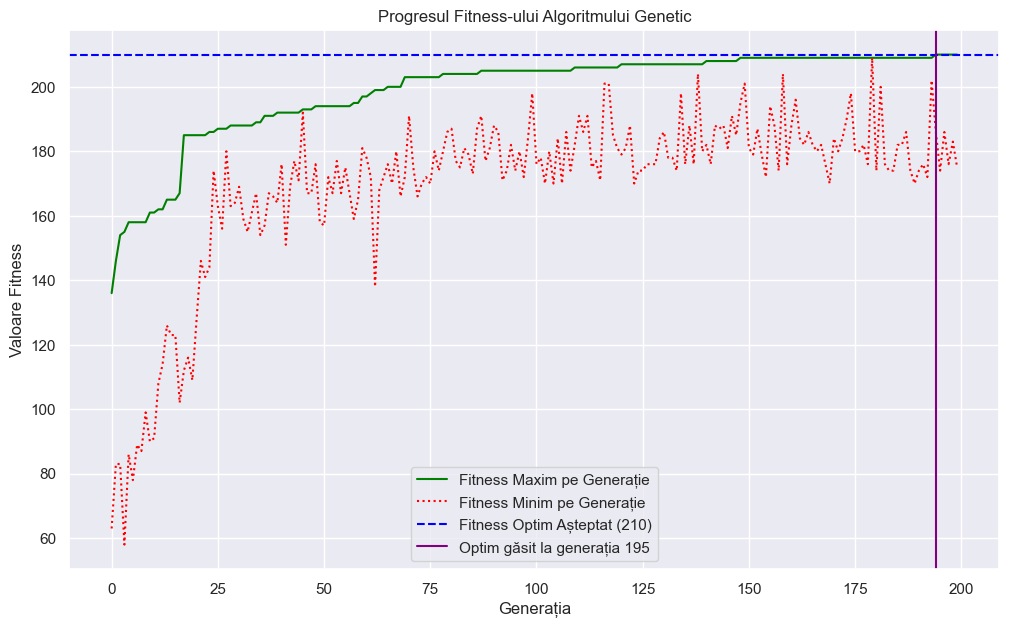

In [12]:
# Apelarea funcției de vizualizare pentru a afișa progresul algoritmului genetic.
# Se utilizează istoricul fitness-ului maxim și minim, generația optimă și datele cromozomului valid.
plot_ga_results(best_fitness_history, worst_fitness_history, found_optimal_gen, valid_chromozome)

### Analiza de Sensibilitate a Ratei de Mutație

Pentru a înțelege cum influențează `rata_de_mutație` performanța algoritmului genetic, vom efectua o analiză de sensibilitate. Vom rula algoritmul de mai multe ori, modificând valoarea ratei de mutație în timp ce menținem ceilalți parametri constanți. Vom analiza cum variază fitness-ul maxim obținut și generația la care a fost găsită soluția optimă în funcție de rata de mutație.

In [13]:
# Definirea unui set de valori pentru rata de mutație pe care le vom testa.
mutation_rates = np.arange(0.01, 0.2, 0.01) # De la 1% la 19%, cu un pas de 1%.

# Liste pentru stocarea rezultatelor analizei de sensibilitate.
best_fitnesses_per_mutation_rate = []
generations_to_optimal_per_mutation_rate = []

print("Rulăm analiza de sensibilitate pentru rata de mutație...")

# Iterăm prin fiecare rată de mutație definită.
for mr in mutation_rates:
    # Rulăm algoritmul genetic cu rata de mutație curentă și o sămânță fixă pentru reproductibilitate.
    # Menținem ceilalți parametri la valorile lor implicite sau definite anterior.
    _, current_best_fitness, _, _, current_found_optimal_gen = run_ga(
        fitness_fn=fitness_func,
        generator=generate_individual,
        generations=200,
        population_size=50,
        elitism=1,
        tournament_k=3,
        crossover_rate=0.9,
        mutation_rate=mr,
        reverse=True,
        verbose=False,
        seed=42 # Utilizăm o sămânță fixă pentru a izola efectul ratei de mutație.
    )

    # Stocăm rezultatele.
    best_fitnesses_per_mutation_rate.append(current_best_fitness)
    generations_to_optimal_per_mutation_rate.append(current_found_optimal_gen)
    print(f"  Rata de Mutație: {mr:.2f}, Fitness Maxim: {current_best_fitness}, Generația Optimă: {current_found_optimal_gen}")

print("Analiza de sensibilitate finalizată.")

Rulăm analiza de sensibilitate pentru rata de mutație...
  Rata de Mutație: 0.01, Fitness Maxim: 202, Generația Optimă: -1
  Rata de Mutație: 0.02, Fitness Maxim: 200, Generația Optimă: -1
  Rata de Mutație: 0.03, Fitness Maxim: 206, Generația Optimă: -1
  Rata de Mutație: 0.04, Fitness Maxim: 204, Generația Optimă: -1
  Rata de Mutație: 0.05, Fitness Maxim: 207, Generația Optimă: -1
  Rata de Mutație: 0.06, Fitness Maxim: 208, Generația Optimă: -1
  Rata de Mutație: 0.07, Fitness Maxim: 209, Generația Optimă: -1
  Rata de Mutație: 0.08, Fitness Maxim: 209, Generația Optimă: -1
  Rata de Mutație: 0.09, Fitness Maxim: 210, Generația Optimă: 105
  Rata de Mutație: 0.10, Fitness Maxim: 208, Generația Optimă: -1
  Rata de Mutație: 0.11, Fitness Maxim: 210, Generația Optimă: 183
  Rata de Mutație: 0.12, Fitness Maxim: 210, Generația Optimă: 127
  Rata de Mutație: 0.13, Fitness Maxim: 210, Generația Optimă: 170
  Rata de Mutație: 0.14, Fitness Maxim: 210, Generația Optimă: 82
  Rata de Mutaț

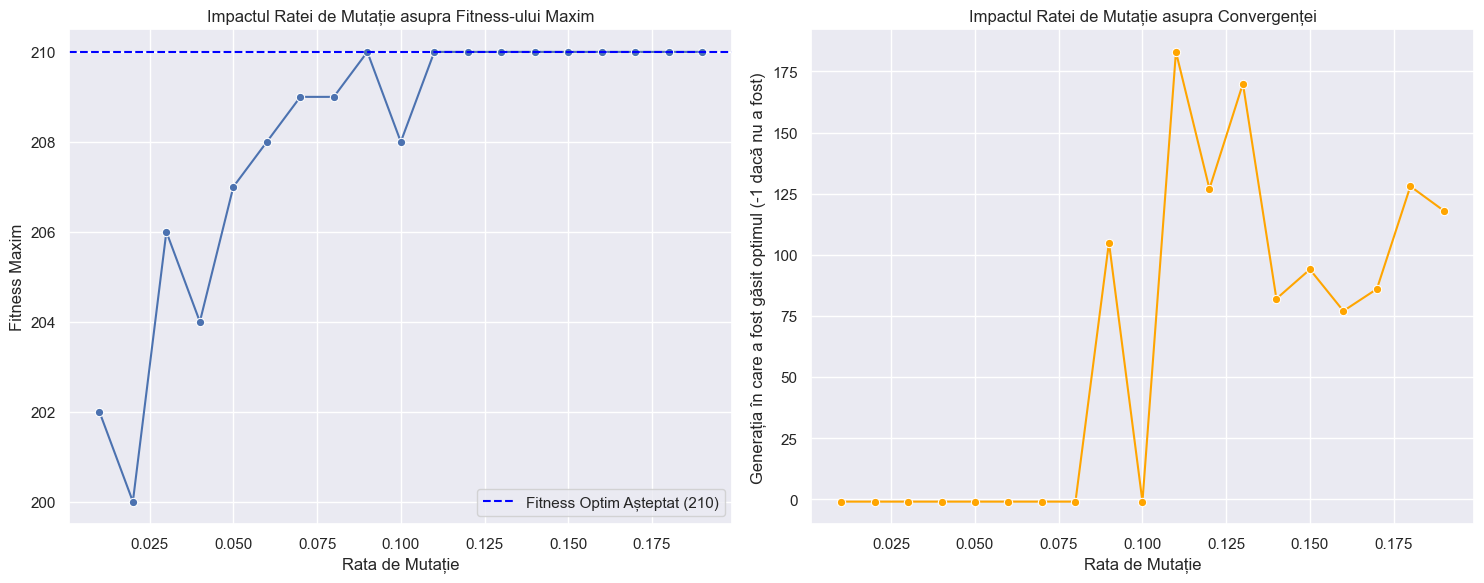

In [14]:
plt.figure(figsize=(15, 6))

# Graficul 1: Fitness-ul maxim în funcție de rata de mutație.
plt.subplot(1, 2, 1) # 1 rând, 2 coloane, primul grafic.
sns.lineplot(x=mutation_rates, y=best_fitnesses_per_mutation_rate, marker='o')
max_inversions = len(valid_chromozome) * (len(valid_chromozome) - 1) // 2
plt.axhline(y=max_inversions, color='blue', linestyle='--', label=f'Fitness Optim Așteptat ({max_inversions})')
plt.xlabel('Rata de Mutație')
plt.ylabel('Fitness Maxim')
plt.title('Impactul Ratei de Mutație asupra Fitness-ului Maxim')
plt.grid(True)
plt.legend()

# Graficul 2: Generația la care a fost găsit optimul în funcție de rata de mutație.
plt.subplot(1, 2, 2) # 1 rând, 2 coloane, al doilea grafic.
sns.lineplot(x=mutation_rates, y=generations_to_optimal_per_mutation_rate, marker='o', color='orange')
plt.xlabel('Rata de Mutație')
plt.ylabel('Generația în care a fost găsit optimul (-1 dacă nu a fost)')
plt.title('Impactul Ratei de Mutație asupra Convergenței')
plt.grid(True)

plt.tight_layout()
plt.show()

### Sumarul Analizei de Sensibilitate a Ratei de Mutație pentru Prezentare

**Obiectiv:** Evaluarea impactului parametrului `rata_de_mutație` asupra performanței algoritmului genetic în rezolvarea problemei sortării permutărilor.

**Metodologie:** Algoritmul genetic a fost rulat pentru un interval de rate de mutație (de la 0.01 la 0.19, cu pas de 0.01), menținând ceilalți parametri (populație, elitism, rata de încrucișare, număr de generații și `seed` pentru reproductibilitate) constanți. Au fost monitorizate **fitness-ul maxim atins** și **generația la care a fost găsită soluția optimă**.

**Constatări Cheie:**

1.  **Rate de Mutație Scăzute (e.g., 0.01 - 0.08):**
    *   Algoritmul a demonstrat o capacitate limitată de a atinge fitness-ul global optim (210) în cadrul celor 200 de generații alocate. Fitness-ul maxim a rămas sub valoarea optimă, indicând o tendință de blocare în optime locale.
    *   Valoarea de `-1` pentru "Generația Optimă" confirmă eșecul de a descoperi permutarea perfect sortată în aceste condiții.

2.  **Rate de Mutație Medii spre Ridicate (e.g., 0.09 - 0.19):**
    *   Pentru majoritatea valorilor din acest interval, algoritmul a reușit să identifice în mod consistent soluția globală optimă (fitness 210).
    *   S-a observat o variație semnificativă în **viteza de convergență**. De exemplu, rate de mutație în jurul valorilor de 0.14-0.16 au condus la găsirea optimului într-un număr mai mic de generații (e.g., 82, 94, 77), sugerând o explorare eficientă a spațiului de căutare fără a introduce o aleatorietate excesivă.

**Concluzie:**

Analiza subliniază rolul crucial al ratei de mutație ca un parametru de echilibru între **explorare** (capacitatea de a descoperi noi regiuni ale spațiului de căutare) și **exploatare** (rafinarea soluțiilor existente). O rată de mutație prea mică restricționează explorarea, conducând la convergență prematură către soluții suboptimale. O rată de mutație bine calibrată facilitează evadarea din optimele locale și accelerează descoperirea soluției globale optime. Alegerea sa depinde de specificul problemei și de structura peisajului de fitness.

### Concluzii Generale

*   **Algoritmii Genetici (AG)** sunt metode de optimizare inspirate din evoluția biologică, eficiente pentru probleme complexe de căutare și optimizare.
*   **Exemplul de Sortare a Permutărilor** a demonstrat modul în care AG-ul poate converge către o soluție optimă (permutare sortată) prin aplicarea operatorilor genetici (selecție, încrucișare, mutație) și a unei funcții de fitness adecvate.
*   **Analiza de Sensibilitate a Ratei de Mutație** a evidențiat importanța echilibrului între **explorare** și **exploatare**. O rată de mutație prea mică poate duce la convergență prematură către optime locale, în timp ce o rată optimă permite o explorare eficientă a spațiului de căutare și o convergență rapidă către optimul global.
*   **Reproducibilitatea** este asigurată prin utilizarea unei *semințe* (seed) pentru generatorul de numere aleatoare, permițând comparații consistente ale performanței algoritmului în diferite scenarii.

Această prezentare a ilustrat conceptele fundamentale și aplicabilitatea Algoritmilor Genetici în rezolvarea problemelor de optimizare.